In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
BASE_DIR = Path("/content/drive/MyDrive/rostat")
MONTHLY_DIR = BASE_DIR / "monthly_forecast"
MONTHLY_DIR.mkdir(parents=True, exist_ok=True)

monthly_data = pd.read_csv(
    MONTHLY_DIR / "monthly_price_index_dataset.csv",
    parse_dates=["month_end"]
)

monthly_data = monthly_data.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

monthly_data["year"] = monthly_data["month_end"].dt.year
monthly_data["month"] = monthly_data["month_end"].dt.month

display(monthly_data.head())

,product_group_code,product_group_name,month_end,mean_price,median_price,n_products,n_observations,is_imputed,year,month,price_index
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,64.656250,65.110,8.0,24.0,False,2016,1,100.000000
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-02-29,65.140750,65.300,8.0,40.0,False,2016,2,100.291814
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,65.685000,65.710,8.0,32.0,False,2016,3,100.921517
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-04-30,66.366563,66.160,8.0,32.0,False,2016,4,101.612656
4,G01,"Хлеб, крупы, мука и макаронные изделия",2016-05-31,67.327750,66.135,8.0,40.0,False,2016,5,101.574259


In [4]:
print("Период:", monthly_data["month_end"].min(), "—", monthly_data["month_end"].max())
print("Категорий:", monthly_data["product_group_code"].nunique())

display(
    monthly_data
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_months=("month_end", "nunique"),
        start_date=("month_end", "min"),
        end_date=("month_end", "max"),
        imputed_months=("is_imputed", "sum")
    )
)

Период: 2016-01-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 9


,product_group_code,product_group_name,n_months,start_date,end_date,imputed_months
0,G01,"Хлеб, крупы, мука и макаронные изделия",120,2016-01-31,2025-12-31,12
1,G02,Молочная продукция и яйца,120,2016-01-31,2025-12-31,12
2,G03,"Мясо, птица, рыба и колбасные изделия",120,2016-01-31,2025-12-31,12
3,G04,"Овощи, фрукты и картофель",120,2016-01-31,2025-12-31,12
4,G05,"Бакалея, масло, сахар, чай, соль",120,2016-01-31,2025-12-31,12
5,G07,"Товары для дома, гигиены и бытовая химия",120,2016-01-31,2025-12-31,12
6,G10,Топливо и транспортные товары,120,2016-01-31,2025-12-31,12
7,G11,Услуги,120,2016-01-31,2025-12-31,12
8,G99,Прочее,120,2016-01-31,2025-12-31,12


In [5]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [6]:
monthly_configs = [
    {
        "model": "SARIMA (0,1,1)(0,1,1,12)",
        "model_type": "SARIMA",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,12)",
        "model_type": "SARIMA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,1)(0,1,1,12)",
        "model_type": "SARIMA",
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (0,1,1)(1,1,0,12)",
        "model_type": "SARIMA",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 0, 12)
    }
]

In [7]:
def run_monthly_naive_one_step(category_df, validation_month, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] < validation_month].copy()
    valid_df = df[df["month_end"] == validation_month].copy()

    if len(valid_df) == 0:
        raise ValueError(f"Нет данных для месяца {validation_month}")

    if len(train_df) < 12:
        raise ValueError("Слишком мало train-данных")

    prev_year_month = validation_month - pd.DateOffset(years=1)

    prev_value = train_df.loc[
        train_df["month_end"] == prev_year_month,
        y_col
    ]

    if len(prev_value) == 0:
        raise ValueError(f"Нет значения за тот же месяц прошлого года: {prev_year_month}")

    yhat = float(prev_value.iloc[0])

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["validation_month"] = validation_month

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_month": validation_month,
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_months": len(train_df),
        "valid_months": len(valid_df),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [8]:
def run_monthly_sarima_one_step(category_df, validation_month, config, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] < validation_month].copy()
    valid_df = df[df["month_end"] == validation_month].copy()

    if len(valid_df) == 0:
        raise ValueError(f"Нет данных для месяца {validation_month}")

    if len(train_df) < 36:
        raise ValueError("Слишком мало train-данных для SARIMA")

    assert train_df["month_end"].max() < validation_month, "Validation month попал в train"

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    model = SARIMAX(
        y_train,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(steps=1)

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = float(yhat.iloc[0]) if hasattr(yhat, "iloc") else float(yhat[0])
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["validation_month"] = validation_month

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": config["model"],
        "model_type": config["model_type"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_month": validation_month,
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_months": len(train_df),
        "valid_months": len(valid_df),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [9]:
validation_months_2025 = pd.date_range(
    start="2025-01-31",
    end="2025-12-31",
    freq="M"
)

monthly_2025_metrics = []
monthly_2025_predictions = []
monthly_2025_models = {}

for validation_month in validation_months_2025:
    print("=" * 100)
    print(f"VALIDATION MONTH: {validation_month.date()}")

    for group_code, category_df in monthly_data.groupby("product_group_code"):
        group_name = category_df["product_group_name"].iloc[0]

        print("-" * 100)
        print(f"Категория: {group_code} — {group_name}")

        category_df = category_df.sort_values("month_end").copy()

        # Seasonal Naive
        try:
            pred, metrics = run_monthly_naive_one_step(
                category_df=category_df,
                validation_month=validation_month
            )

            monthly_2025_predictions.append(pred)
            monthly_2025_metrics.append(metrics)

            print(
                f"Seasonal Naive | "
                f"MAPE={metrics['MAPE']:.3f}, "
                f"sMAPE={metrics['sMAPE']:.3f}"
            )

        except Exception as e:
            print("Ошибка Seasonal Naive:", e)

        # SARIMA
        for config in monthly_configs:
            try:
                result, pred, metrics = run_monthly_sarima_one_step(
                    category_df=category_df,
                    validation_month=validation_month,
                    config=config
                )

                monthly_2025_predictions.append(pred)
                monthly_2025_metrics.append(metrics)

                model_key = f"{validation_month.date()}_{group_code}_{config['model']}"
                monthly_2025_models[model_key] = result

                print(
                    f"{config['model']} | "
                    f"MAPE={metrics['MAPE']:.3f}, "
                    f"sMAPE={metrics['sMAPE']:.3f}"
                )

            except Exception as e:
                print(f"Ошибка {config['model']}: {e}")

monthly_2025_metrics_df = pd.DataFrame(monthly_2025_metrics)
monthly_2025_predictions_df = pd.concat(monthly_2025_predictions, ignore_index=True)

display(monthly_2025_metrics_df.head())

VALIDATION MONTH: 2025-01-31
----------------------------------------------------------------------------------------------------
Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=4.317, sMAPE=4.412
SARIMA (0,1,1)(0,1,1,12) | MAPE=1.664, sMAPE=1.678
SARIMA (1,1,0)(0,1,1,12) | MAPE=1.435, sMAPE=1.446
SARIMA (1,1,1)(0,1,1,12) | MAPE=1.437, sMAPE=1.447
SARIMA (0,1,1)(1,1,0,12) | MAPE=2.476, sMAPE=2.507
----------------------------------------------------------------------------------------------------
Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=8.802, sMAPE=9.207
SARIMA (0,1,1)(0,1,1,12) | MAPE=0.020, sMAPE=0.020
SARIMA (1,1,0)(0,1,1,12) | MAPE=0.228, sMAPE=0.228
SARIMA (1,1,1)(0,1,1,12) | MAPE=0.081, sMAPE=0.081
SARIMA (0,1,1)(1,1,0,12) | MAPE=0.420, sMAPE=0.421
----------------------------------------------------------------------------------------------------
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Seasonal Naive | MAPE=5.

,MAE,RMSE,MAPE,sMAPE,model,model_type,product_group_code,product_group_name,validation_month,train_start,train_end,valid_start,valid_end,train_months,valid_months,AIC,BIC
0,6.673322,6.673322,4.316940,4.412175,Seasonal Naive,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2025-01-31,2016-01-31,2024-12-31,2025-01-31,2025-01-31,108,1,NaN,NaN
1,2.572605,2.572605,1.664206,1.678170,"SARIMA (0,1,1)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2025-01-31,2016-01-31,2024-12-31,2025-01-31,2025-01-31,108,1,-430.057637,-422.874290
2,2.218877,2.218877,1.435381,1.445757,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2025-01-31,2016-01-31,2024-12-31,2025-01-31,2025-01-31,108,1,-455.403538,-448.183381
3,2.220901,2.220901,1.436690,1.447085,"SARIMA (1,1,1)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2025-01-31,2016-01-31,2024-12-31,2025-01-31,2025-01-31,108,1,-447.007113,-437.429317
4,3.827424,3.827424,2.475942,2.506978,"SARIMA (0,1,1)(1,1,0,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2025-01-31,2016-01-31,2024-12-31,2025-01-31,2025-01-31,108,1,-420.132672,-412.876150


In [10]:
leak_check = monthly_2025_metrics_df.copy()

leak_check["train_end"] = pd.to_datetime(leak_check["train_end"])
leak_check["validation_month"] = pd.to_datetime(leak_check["validation_month"])

leak_check["train_uses_validation_month"] = (
    leak_check["train_end"] >= leak_check["validation_month"]
)

display(
    leak_check[
        [
            "validation_month",
            "model",
            "product_group_code",
            "product_group_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "train_uses_validation_month"
        ]
    ].sort_values(["validation_month", "product_group_code", "model"])
)

print("Есть ли утечка validation month в train?")
print(leak_check["train_uses_validation_month"].any())

,validation_month,model,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_uses_validation_month
1,2025-01-31,"SARIMA (0,1,1)(0,1,1,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-01-31,False
4,2025-01-31,"SARIMA (0,1,1)(1,1,0,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-01-31,False
2,2025-01-31,"SARIMA (1,1,0)(0,1,1,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-01-31,False
3,2025-01-31,"SARIMA (1,1,1)(0,1,1,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-01-31,False
0,2025-01-31,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-01-31,False
...,...,...,...,...,...,...,...,...,...
527,2025-12-31,"SARIMA (0,1,1)(0,1,1,12)",G99,Прочее,2016-01-31,2025-11-30,2025-12-31,2025-12-31,False
530,2025-12-31,"SARIMA (0,1,1)(1,1,0,12)",G99,Прочее,2016-01-31,2025-11-30,2025-12-31,2025-12-31,False
528,2025-12-31,"SARIMA (1,1,0)(0,1,1,12)",G99,Прочее,2016-01-31,2025-11-30,2025-12-31,2025-12-31,False
529,2025-12-31,"SARIMA (1,1,1)(0,1,1,12)",G99,Прочее,2016-01-31,2025-11-30,2025-12-31,2025-12-31,False


Есть ли утечка validation month в train?
False


In [11]:
best_monthly_2025_by_category_month = (
    monthly_2025_metrics_df
    .sort_values(["validation_month", "product_group_code", "MAPE"])
    .groupby(["validation_month", "product_group_code"])
    .head(1)
    .reset_index(drop=True)
)

best_monthly_2025_display = best_monthly_2025_by_category_month.copy()

for col in ["MAE", "RMSE", "MAPE", "sMAPE", "AIC", "BIC"]:
    if col in best_monthly_2025_display.columns:
        best_monthly_2025_display[col] = best_monthly_2025_display[col].round(3)

display(
    best_monthly_2025_display[
        [
            "validation_month",
            "product_group_code",
            "product_group_name",
            "model",
            "model_type",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ]
)

,validation_month,product_group_code,product_group_name,model,model_type,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,2025-01-31,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",SARIMA,2.219,2.219,1.435,1.446,2016-01-31,2024-12-31,2025-01-31,2025-01-31
1,2025-01-31,G02,Молочная продукция и яйца,"SARIMA (0,1,1)(0,1,1,12)",SARIMA,0.038,0.038,0.020,0.020,2016-01-31,2024-12-31,2025-01-31,2025-01-31
2,2025-01-31,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,1)(1,1,0,12)",SARIMA,0.235,0.235,0.139,0.139,2016-01-31,2024-12-31,2025-01-31,2025-01-31
3,2025-01-31,G04,"Овощи, фрукты и картофель","SARIMA (0,1,1)(0,1,1,12)",SARIMA,6.328,6.328,3.416,3.359,2016-01-31,2024-12-31,2025-01-31,2025-01-31
4,2025-01-31,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (1,1,0)(0,1,1,12)",SARIMA,2.268,2.268,1.158,1.165,2016-01-31,2024-12-31,2025-01-31,2025-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2025-12-31,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (0,1,1)(0,1,1,12)",SARIMA,0.174,0.174,0.082,0.082,2016-01-31,2025-11-30,2025-12-31,2025-12-31
104,2025-12-31,G07,"Товары для дома, гигиены и бытовая химия","SARIMA (0,1,1)(0,1,1,12)",SARIMA,0.982,0.982,0.600,0.598,2016-01-31,2025-11-30,2025-12-31,2025-12-31
105,2025-12-31,G10,Топливо и транспортные товары,"SARIMA (1,1,1)(0,1,1,12)",SARIMA,0.869,0.869,0.462,0.461,2016-01-31,2025-11-30,2025-12-31,2025-12-31
106,2025-12-31,G11,Услуги,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,0.696,0.696,0.349,0.349,2016-01-31,2025-11-30,2025-12-31,2025-12-31


In [12]:
best_keys = best_monthly_2025_by_category_month[
    [
        "validation_month",
        "product_group_code",
        "model"
    ]
].copy()

monthly_2025_best_predictions = monthly_2025_predictions_df.merge(
    best_keys,
    on=[
        "validation_month",
        "product_group_code",
        "model"
    ],
    how="inner"
)

monthly_2025_best_predictions = monthly_2025_best_predictions.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

display(monthly_2025_best_predictions.head(20))

,month_end,year,month,product_group_code,product_group_name,price_index,is_imputed,y,yhat,model,model_type,validation_month
0,2025-01-31,2025,1,G01,"Хлеб, крупы, мука и макаронные изделия",154.584549,False,154.584549,152.365672,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,2025-01-31
1,2025-02-28,2025,2,G01,"Хлеб, крупы, мука и макаронные изделия",154.761173,False,154.761173,155.835893,"SARIMA (0,1,1)(1,1,0,12)",SARIMA,2025-02-28
2,2025-03-31,2025,3,G01,"Хлеб, крупы, мука и макаронные изделия",156.512057,False,156.512057,155.253641,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,2025-03-31
3,2025-04-30,2025,4,G01,"Хлеб, крупы, мука и макаронные изделия",157.587160,False,157.587160,156.898306,"SARIMA (0,1,1)(1,1,0,12)",SARIMA,2025-04-30
4,2025-05-31,2025,5,G01,"Хлеб, крупы, мука и макаронные изделия",158.332053,False,158.332053,157.202525,"SARIMA (1,1,1)(0,1,1,12)",SARIMA,2025-05-31
5,2025-06-30,2025,6,G01,"Хлеб, крупы, мука и макаронные изделия",159.345723,False,159.345723,159.330808,"SARIMA (0,1,1)(0,1,1,12)",SARIMA,2025-06-30
6,2025-07-31,2025,7,G01,"Хлеб, крупы, мука и макаронные изделия",160.344033,False,160.344033,160.035972,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,2025-07-31
7,2025-08-31,2025,8,G01,"Хлеб, крупы, мука и макаронные изделия",161.196437,False,161.196437,161.073610,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,2025-08-31
8,2025-09-30,2025,9,G01,"Хлеб, крупы, мука и макаронные изделия",161.680233,False,161.680233,161.546512,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,2025-09-30
9,2025-10-31,2025,10,G01,"Хлеб, крупы, мука и макаронные изделия",163.254492,False,163.254492,162.619462,"SARIMA (1,1,1)(0,1,1,12)",SARIMA,2025-10-31


In [13]:
monthly_2025_model_type_summary = (
    monthly_2025_metrics_df
    .groupby("model_type", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_MAPE")
)

display(monthly_2025_model_type_summary.round(3))

,model_type,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_runs
0,SARIMA,2.689,2.689,1.34,1.326,2.646,0.000,18.554,432
1,Seasonal Naive,18.702,18.702,9.59,10.191,6.217,0.068,34.652,99


In [14]:
monthly_2025_summary_by_month = (
    monthly_2025_metrics_df
    .groupby(["validation_month", "model_type"], as_index=False)
    .agg(
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        n_runs=("MAPE", "size")
    )
    .sort_values(["validation_month", "mean_MAPE"])
)

display(monthly_2025_summary_by_month.round(3))

,validation_month,model_type,mean_MAPE,mean_sMAPE,mean_MAE,mean_RMSE,n_runs
0,2025-01-31,SARIMA,1.796,1.810,3.296,3.296,36
1,2025-01-31,Seasonal Naive,9.414,10.099,17.086,17.086,9
2,2025-02-28,SARIMA,1.304,1.295,2.424,2.424,36
3,2025-03-31,SARIMA,1.420,1.441,2.801,2.801,36
4,2025-03-31,Seasonal Naive,10.098,10.897,19.322,19.322,9
5,2025-04-30,SARIMA,1.029,1.051,2.267,2.267,36
6,2025-04-30,Seasonal Naive,11.204,12.399,23.405,23.405,9
7,2025-05-31,SARIMA,0.729,0.702,1.781,1.781,36
8,2025-05-31,Seasonal Naive,10.979,12.096,24.037,24.037,9
9,2025-06-30,SARIMA,0.984,0.994,2.291,2.291,36


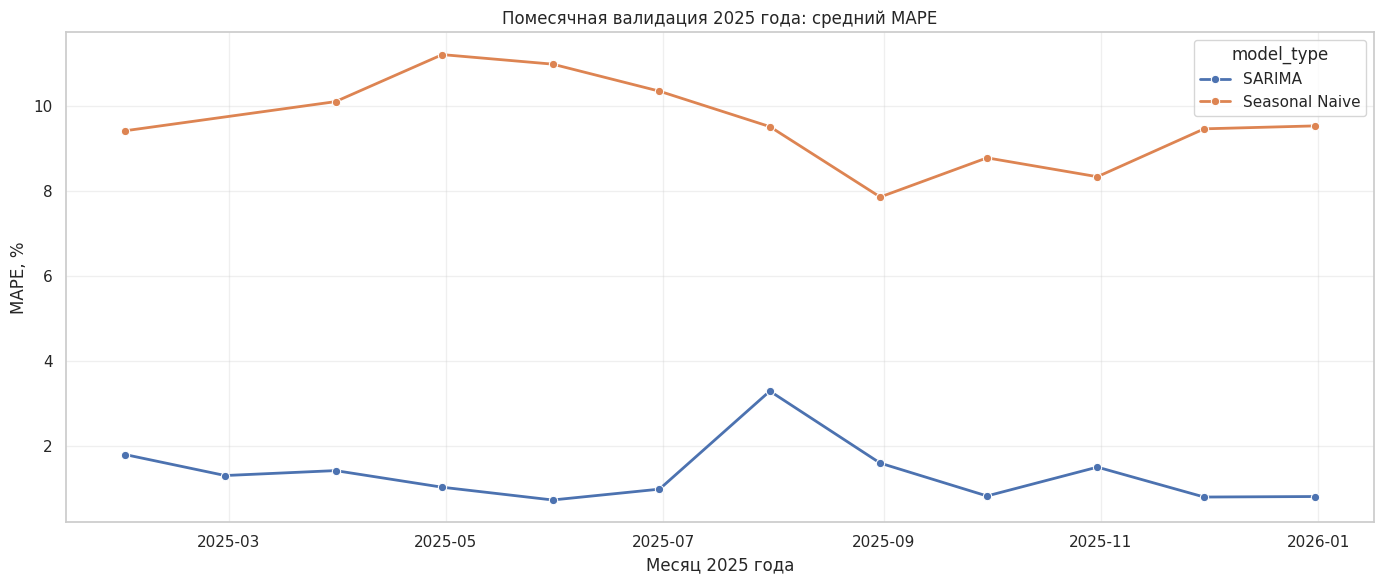

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_2025_summary_by_month,
    x="validation_month",
    y="mean_MAPE",
    hue="model_type",
    marker="o",
    linewidth=2
)

plt.title("Помесячная валидация 2025 года: средний MAPE")
plt.xlabel("Месяц 2025 года")
plt.ylabel("MAPE, %")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

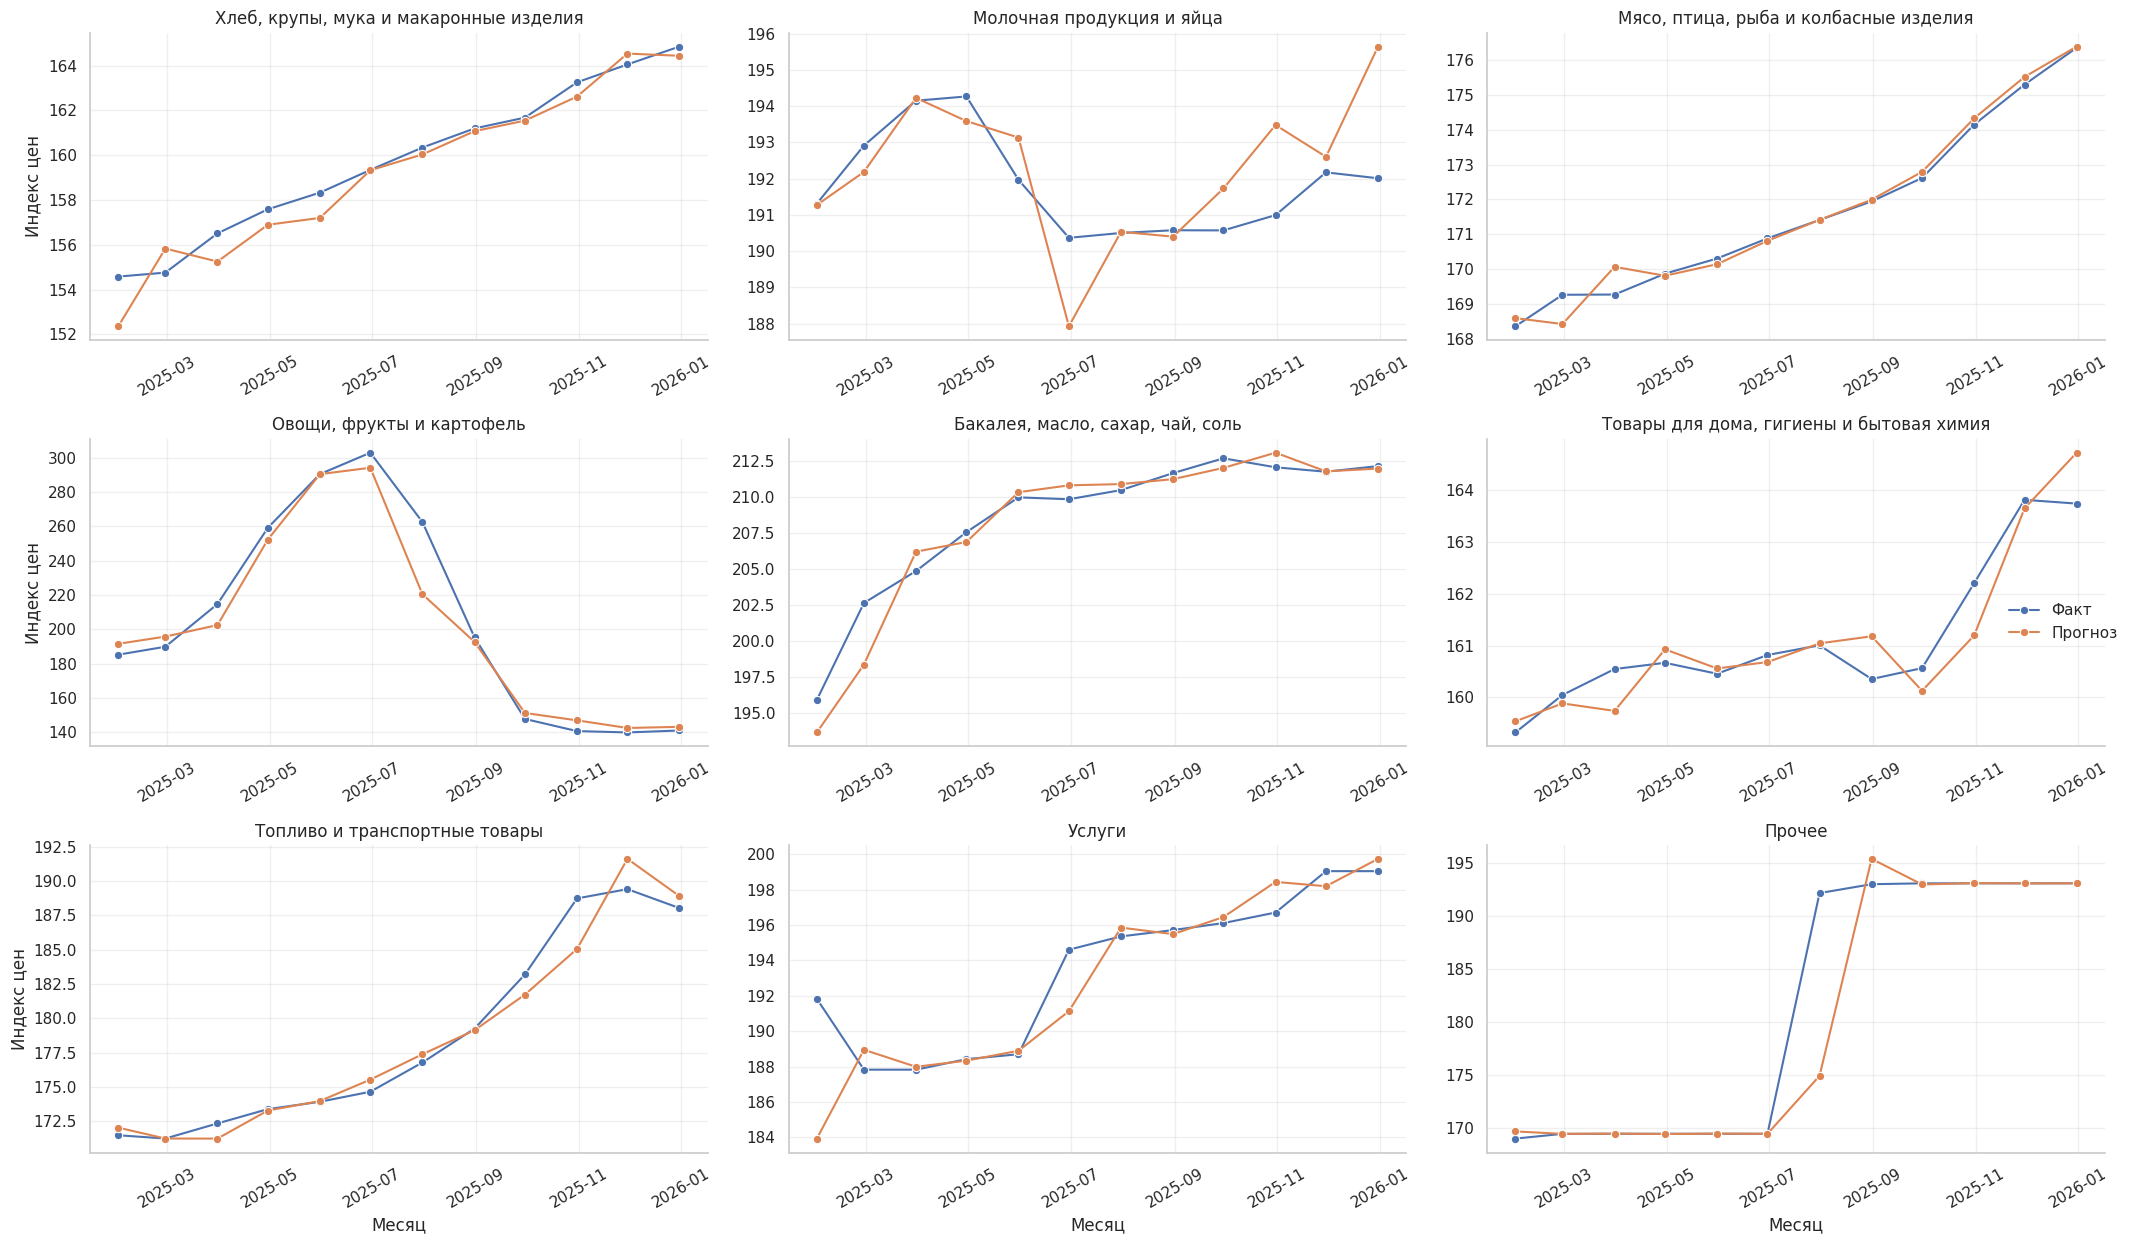

In [16]:
plot_monthly_2025 = pd.concat(
    [
        monthly_2025_best_predictions[
            [
                "month_end",
                "product_group_name",
                "y"
            ]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        monthly_2025_best_predictions[
            [
                "month_end",
                "product_group_name",
                "yhat"
            ]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_monthly_2025,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
monthly_2025_metrics_df.to_csv(
    MONTHLY_DIR / "monthly_2025_cv_all_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

best_monthly_2025_by_category_month.to_csv(
    MONTHLY_DIR / "monthly_2025_best_models_by_category_month.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_2025_predictions_df.to_csv(
    MONTHLY_DIR / "monthly_2025_cv_all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_2025_best_predictions.to_csv(
    MONTHLY_DIR / "monthly_2025_best_predictions_combined.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_2025_model_type_summary.to_csv(
    MONTHLY_DIR / "monthly_2025_model_type_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_2025_summary_by_month.to_csv(
    MONTHLY_DIR / "monthly_2025_summary_by_month.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", MONTHLY_DIR)

Файлы сохранены в: /content/drive/MyDrive/rostat/monthly_forecast
